## 5.2. Renewables focus (2023-2026)

In this part, the same regression analysis will be displayed, taking into consideration the period of time that goes from May 2023 to May 2026. 
Since the previous analylsis showed a structural decrease of prices with the increase of renewables production, that deviated from the typical linear rleationship between the two variables, it is appropriate to use updated information.  
This means that, instead of taking into consideration 2023-2025 dataset, 2023-2026 dataset shifted by 5 months is used for comparison and insights.

In [1]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean/updated')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'merged-dataset.csv')

In [2]:
# filter dataset by date
data = data[
    (data['Date'] >= '2023-05-01 00:00:00')
    &
    (data['Date'] < '2026-06-01 00:00:00')
] 
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
2878,2023-05-01 00:00:00,114.35000,0.63,2.50,0.00,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
2879,2023-05-01 01:00:00,112.00000,0.63,2.40,0.00,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2880,2023-05-01 02:00:00,110.00000,0.63,2.35,0.00,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
2881,2023-05-01 03:00:00,106.75000,0.63,2.37,0.00,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
2882,2023-05-01 04:00:00,108.98000,0.63,2.40,0.00,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025
...,...,...,...,...,...,...,...,...,...,...,...,...
29867,2026-05-31 19:00:00,152.93646,0.60,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
29868,2026-05-31 20:00:00,162.48019,0.60,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
29869,2026-05-31 21:00:00,161.37194,0.60,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
29870,2026-05-31 22:00:00,158.47406,0.60,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025


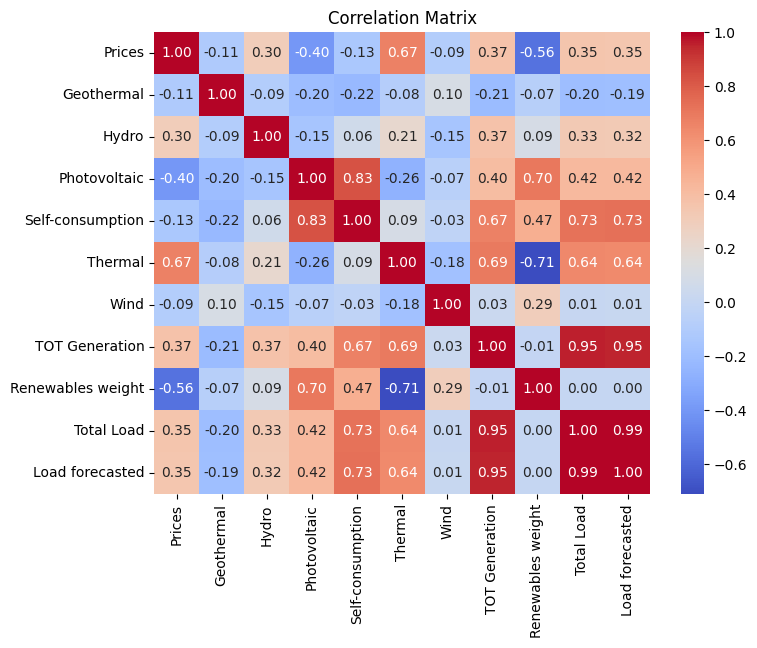

In [3]:
# correlation matrix
corr_matrix = data.corr(numeric_only=True)

# display heated matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

The correlation analysis highlights clear and economically consistent relationships between electricity prices and the main generation technologies in the Italian power market.  
Prices are strongly positively correlated with **thermal** generation (0.67), confirming the central role of gas-fired plants in the Italian electricity system, where they frequently act as marginal units in the price-setting process. A positive correlation is also observed with **hydro** generation (0.30), which may reflect the strategic nature of reservoir hydro plants, typically dispatched during high-price periods rather than implying a direct price-setting role.

In contrast, **photovoltaic** generation shows a relatively strong negative correlation with prices (-0.40), consistent with the merit-order effect, whereby zero-marginal-cost renewable production displaces more expensive generation sources and reduces market clearing prices. This relationship also reflects increasing solar cannibalization effects, as higher solar penetration tends to depress prices during daylight hours, strengthening the economic rationale for storage technologies such as batteries.

**Wind** and **geothermal** generation exhibit weak correlations with prices (-0.09 and -0.11 respectively), suggesting a limited direct linear relationship, likely due to their lower marginal impact and more stable or less concentrated production profiles within the Italian generation mix.

At an aggregate level, total load and total generation show moderate positive correlations with prices (0.35 and 0.37), indicating that higher demand conditions are associated with higher electricity prices, as more expensive generation units are required to meet consumption. Overall, these results are consistent with the expected functioning of the Italian wholesale electricity market and support the presence of a merit-order driven price formation mechanism.

### Cross-period comparison (2021–2025 vs post-2022 shifted window)

To assess the robustness of the observed relationships, the correlation structure of the post-2022 shifted sample (2023–2026 window) is compared with a longer historical period (2021–2025), which provides a broader structural benchmark of the Italian electricity market.

The comparison highlights notable differences in the strength and structure of correlations between electricity prices and key generation technologies. In the post-2022 period, prices exhibit a stronger association with thermal generation and a more pronounced negative relationship with renewable penetration, particularly photovoltaic generation. This suggests a more polarised market regime, where price formation is more directly influenced by the interaction between gas-fired generation and renewable output.

In contrast, the 2021–2025 sample shows weaker correlations between prices and both thermal generation and renewables, indicating a more diffuse relationship between generation mix and price dynamics when observed over a longer time horizon. In particular, the correlation between prices and photovoltaic generation becomes substantially weaker, while the negative association with renewable share is reduced in magnitude. Similarly, the link between prices and demand-related variables (load and total generation) is also attenuated.

Hydropower displays a sign reversal across the two periods, moving from a positive association in the post-2022 sample to a slightly negative correlation in the longer window. This may reflect a shift from short-term strategic dispatch behaviour during high-price episodes to a more structurally driven production pattern over the full sample.

Overall, the evidence suggests that the post-2022 period captures a more extreme and concentrated market regime, likely influenced by recent energy price shocks and heightened volatility in gas markets, while the longer 2021–2025 window reflects a more averaged structural relationship in which individual drivers exert a weaker marginal influence on price formation.

### Bivariate Linear Regression with OLS

In [4]:
data = data.rename(
    columns={'Renewables weight': 'Renewables_weight'}
)

data.head()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted
2878,2023-05-01 00:00:00,114.35,0.63,2.50,0.0,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
2879,2023-05-01 01:00:00,112.00,0.63,2.40,0.0,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2880,2023-05-01 02:00:00,110.00,0.63,2.35,0.0,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
2881,2023-05-01 03:00:00,106.75,0.63,2.37,0.0,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
2882,2023-05-01 04:00:00,108.98,0.63,2.40,0.0,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025


In [5]:
data.tail()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted
29867,2026-05-31 19:00:00,152.93646,0.6,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
29868,2026-05-31 20:00:00,162.48019,0.6,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
29869,2026-05-31 21:00:00,161.37194,0.6,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
29870,2026-05-31 22:00:00,158.47406,0.6,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025
29871,2026-05-31 23:00:00,150.70448,0.6,6.08,0.00,1.388,13.30,1.97,21.95,0.394077,28210.50000,28413.50000


In [6]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

VAR_X = 'Renewables_weight'
VAR_Y = 'Prices'

formula = f'{VAR_Y} ~ {VAR_X}'

model = smf.ols(formula, data=data).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2023 - 2026)\n')
print(model.summary())


Linear Regression Model - Prices and Renewables (2023 - 2026)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                 1.226e+04
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:11:54   Log-Likelihood:            -1.2557e+05
No. Observations:               26994   AIC:                         2.511e+05
Df Residuals:                   26992   BIC:                         2.512e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

#### Visualizations

In [7]:
params = model.params

# x values
ax_x = 'Renewables_weight'
x = np.linspace(0, 1, 100)

# coefficients
b0 = model.params['Intercept']
b1 = model.params['Renewables_weight']

# f lines
y_d_0 = b0 + b1 * x 


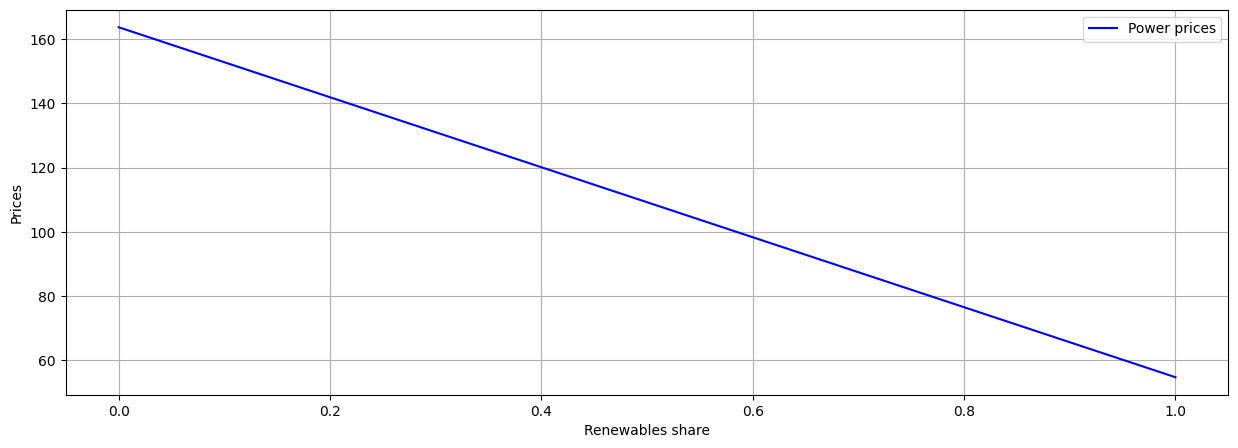

In [8]:
# matplotlib graph
plt.figure(figsize=(15, 5))
# plt.plot(x, y_d_1, color='sandybrown', label='D = 1 (no interaction)', )
plt.plot(x, y_d_0, color='blue', label='Power prices')
# plt.plot(x, y_interaction, color='red', label='D = 1 (interaction)')
plt.xlabel("Renewables share")
plt.ylabel("Prices")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import plotly.express as px
import plotly.graph_objects as go 

fig = px.scatter(
    data, 
    x='Renewables_weight', 
    y='Prices', 
    hover_data={
        'Renewables_weight': True,
        'Prices': True, 
        'Date': True
    }, 
    opacity=0.05
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_d_0,
        mode='lines',
        name='Power Prices',
        line=dict(width=4)
    )
)

fig.update_layout(
    title='Linear Regression (OLS)',
    xaxis_title='Renewables share',
    yaxis_title='Prices',
    template='simple_white'
)

fig.show()

The OLS results confirm a statistically significant negative relationship between renewable penetration and electricity prices. In the 2023–2026 specification, the coefficient of the renewable share is negative and highly significant, suggesting that higher renewable penetration is associated with lower wholesale electricity prices. However, the model explains approximately 31% of price variability, indicating that additional structural and market factors remain relevant in price formation.

The extended specification over the 2021–2025 sample, which includes regime indicators and interaction terms, reveals a more nuanced relationship. While the average effect of renewable penetration remains negative, its magnitude varies significantly across regimes. In particular, the interaction terms suggest that the impact of renewables on prices is not stable over time and is partially dependent on the prevailing market regime.

Overall, the results indicate that renewable penetration consistently exerts downward pressure on electricity prices, but the strength of this effect is time-varying and sensitive to market conditions, particularly in periods characterised by structural changes in energy markets.

In [10]:
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
import numpy as np
 
# Scatter
fig = px.scatter(
    data,
    x='Renewables_weight',
    y='Prices',
    hover_data=['Date'],
    opacity=0.05
)
 
# ------------------
# OLS Trendline
# ------------------
X = sm.add_constant(data['Renewables_weight'])
ols_model = sm.OLS(data['Prices'], X).fit()
 
x_ols = np.linspace(
    data['Renewables_weight'].min(),
    data['Renewables_weight'].max(),
    100
)
 
y_ols = ols_model.predict(sm.add_constant(x_ols))
 
fig.add_trace(
    go.Scatter(
        x=x_ols,
        y=y_ols,
        mode='lines',
        name='OLS',
        line=dict(color='red', width=3)
    )
)
 
# ------------------
# LOWESS Trendline
# ------------------
lowess_fit = lowess(
    endog=data['Prices'],
    exog=data['Renewables_weight'],
    frac=0.2  # da regolare
)
 
fig.add_trace(
    go.Scatter(
        x=lowess_fit[:, 0],
        y=lowess_fit[:, 1],
        mode='lines',
        name='LOWESS',
        line=dict(color='green', width=3)
    )
)
 
fig.update_layout(
    title='OLS vs LOWESS',
    xaxis_title='Renewables Share',
    yaxis_title='Prices',
    template='simple_white'
)
 
fig.show()

Since linear trendline is useful for simple prediction, but is not very representative of the current reality, a Locally Weighted Scatterplot Smoothing (LOWESS) regression is displayed on the graph, in order to observe the current trend of power spot prices during renewables prenetration, suggesting that the OLS model is overestimating the effects of renewables share on PUN.
 
Overall, the results indicate that renewable penetration consistently exerts downward pressure on electricity prices, but the strength of this effect is time-varying and sensitive to market conditions, particularly in periods characterised by structural changes in energy markets.

In [11]:
# robust model to heteroskedasticity and autocorrelation
robust_model = smf.ols(
    formula,
    data=data
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags':24}
)

print(f'\nRobust Linear Regression Model - Prices and Renewables (2023 - 2026)\n')
print(robust_model.summary())


Robust Linear Regression Model - Prices and Renewables (2023 - 2026)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     1477.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:13:09   Log-Likelihood:            -1.2557e+05
No. Observations:               26994   AIC:                         2.511e+05
Df Residuals:                   26992   BIC:                         2.512e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

The HAC-robust OLS specification confirms a statistically significant negative relationship between renewable penetration and electricity prices in the 2023–2026 period. The estimated coefficient for the renewable share remains stable at -109.13, indicating that higher renewable penetration is associated with lower wholesale electricity prices. Importantly, the use of HAC (heteroskedasticity and autocorrelation consistent) standard errors strengthens the reliability of the inference, as it accounts for potential serial correlation and heteroskedasticity typically present in electricity market time series data.

The coefficient remains highly statistically significant, with a z-statistic of -38.43, confirming that the relationship is not driven by heteroskedastic noise or temporal dependence. However, the explanatory power of the model remains moderate (R² = 0.312), suggesting that while renewable penetration is a relevant driver of prices, a substantial portion of price variation is explained by additional structural factors not included in the model, such as fuel prices, demand dynamics, and system constraints.

Overall, the HAC-robust results reinforce the robustness of the negative association between renewable penetration and electricity prices, supporting the presence of a merit-order consistent price suppression effect in the Italian electricity market during the post-2022 period.